In [1]:
# Import relevant libraries. 
# Note that `partisan_dislocation` can be 
# installed from pypi by running 
# `pip install partisan_dislocation` 
# at the command line. 

import partisan_dislocation as pdn
import geopandas as gpd

## Loading and Preparing Data

In [ ]:
# The repository fop
nc = gpd.read_file('NC_Processed/output/NC_Processed_Precincts.shp')

<Axes: >

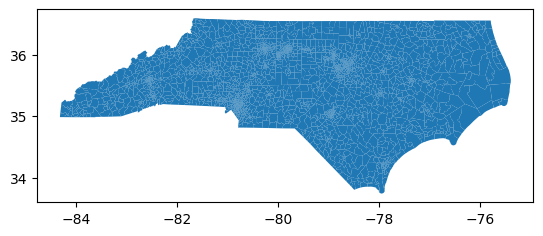

In [3]:
# Subset to North Carolina
nc.plot()

In [4]:
nc = nc.to_crs('esri:102010')

## Make Voter Points and Measure Nearest Neighbor Partisanship

In [59]:
voters = pdn.random_points_in_polygon(nc, p=0.001, 
                                      dem_vote_count="G24PREDHAR", 
                                      repub_vote_count="G24PRERTRU")

In [60]:
voters.head()

,dem,geometry
0,0,POINT (1400833.755 -324091.020)
1,0,POINT (1398701.355 -331566.491)
2,0,POINT (1397962.558 -324668.877)
3,0,POINT (1403954.838 -331267.197)
4,0,POINT (1399087.107 -317859.980)


In [118]:
index = 0
precincts = []
precinct_ids = []
for precinct in nc["geometry"]:
    for voter in voters["geometry"]:
        if precinct.contains(voter):
            precincts.append(precinct)
            precinct_ids.append(index)
    index+=1

In [119]:
voters["precinct_ids"] = precinct_ids
voters["precincts"] = precincts

In [83]:
voters.head()

,dem,geometry,precincts,precinct_ids
0,0,POINT (1400833.755 -324091.020),POLYGON ((1396759.5572422305 -334367.966874143...,0
1,0,POINT (1398701.355 -331566.491),POLYGON ((1396759.5572422305 -334367.966874143...,0
2,0,POINT (1397962.558 -324668.877),POLYGON ((1396759.5572422305 -334367.966874143...,0
3,0,POINT (1403954.838 -331267.197),POLYGON ((1396759.5572422305 -334367.966874143...,0
4,0,POINT (1399087.107 -317859.980),POLYGON ((1394490.6611288986 -321021.248497435...,1


In [84]:
voters_w_knn = pdn.calculate_voter_knn(voters, k=700, target_column='dem')

In [85]:
voters_w_knn.head()

,dem,geometry,precincts,precinct_ids,knn_shr_dem
0,0,POINT (1400833.755 -324091.020),POLYGON ((1396759.5572422305 -334367.966874143...,0,0.628571
1,0,POINT (1398701.355 -331566.491),POLYGON ((1396759.5572422305 -334367.966874143...,0,0.592857
2,0,POINT (1397962.558 -324668.877),POLYGON ((1396759.5572422305 -334367.966874143...,0,0.608571
3,0,POINT (1403954.838 -331267.197),POLYGON ((1396759.5572422305 -334367.966874143...,0,0.631429
4,0,POINT (1399087.107 -317859.980),POLYGON ((1394490.6611288986 -321021.248497435...,1,0.625714


## Calculating Dislocation

<Axes: >

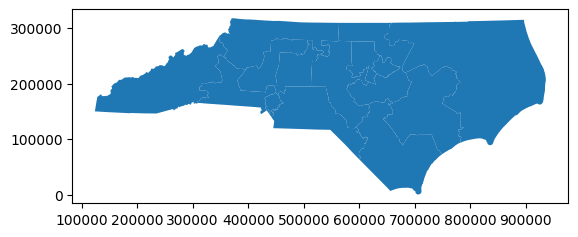

In [ ]:
# Subset to North Carolina
nc_congress = gpd.read_file('NC_Processed/nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp')
nc_congress.plot()

In [120]:
dislocation_p = pdn.calculate_dislocation(voters_w_knn, nc_congress, 
                                        knn_column='knn_shr_dem', 
                                        dem_column='dem')

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\partisan_dislocation\partisan_dislocation.py:226: FutureWarning: The provided callable <function mean at 0x0000022FFE7C9750> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ].transform(np.mean)


In [121]:
dislocation_p["precinct"] = precincts
dislocation_p["precinct_ids"] = precinct_ids

In [122]:
dislocation_p.head()

,dem,knn_shr_dem,district_dem_share,partisan_dislocation,geometry,precinct,precinct_ids
0,0,0.628571,0.455206,-0.173366,POINT (1400833.755 -324091.020),POLYGON ((1396759.5572422305 -334367.966874143...,0
1,0,0.592857,0.455206,-0.137651,POINT (1398701.355 -331566.491),POLYGON ((1396759.5572422305 -334367.966874143...,0
2,0,0.608571,0.455206,-0.153366,POINT (1397962.558 -324668.877),POLYGON ((1396759.5572422305 -334367.966874143...,0
3,0,0.631429,0.455206,-0.176223,POINT (1403954.838 -331267.197),POLYGON ((1396759.5572422305 -334367.966874143...,0
4,0,0.625714,0.455206,-0.170508,POINT (1399087.107 -317859.980),POLYGON ((1394490.6611288986 -321021.248497435...,1


In [125]:
party_precinct = dislocation_p.groupby('precinct_ids', as_index=False).agg({
    'precinct': 'first',
    'partisan_dislocation': 'mean',
})

In [126]:
nc["Non_NH_Black"] = nc["Total"] - nc["NH_Black"]

In [15]:
black_pop = pdn.random_points_in_polygon(nc, p=0.001, 
                                      dem_vote_count="NH_Black", 
                                      repub_vote_count="Non_NH_Black")

In [124]:
index = 0
precincts_b = []
precinct_ids_b = []
for precinct in nc["geometry"]:
    for voter in black_pop["geometry"]:
        if precinct.contains(voter):
            precincts_b.append(precinct)
            precinct_ids_b.append(index)
    index+=1

In [107]:
black_pop_w_knn = pdn.calculate_voter_knn(black_pop, k=700, target_column='dem')

In [108]:
dislocation_b = pdn.calculate_dislocation(black_pop_w_knn, nc_congress, 
                                        knn_column='knn_shr_dem', 
                                        dem_column='dem')

C:\Users\angel\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\partisan_dislocation\partisan_dislocation.py:226: FutureWarning: The provided callable <function mean at 0x0000022FFE7C9750> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  ].transform(np.mean)


In [127]:
dislocation_b["precinct"] = precincts_b
dislocation_b["precinct_id"] = precinct_ids_b

In [128]:
dislocation_b.head()

,dem,knn_shr_dem,district_dem_share,partisan_dislocation,geometry,precinct,precinct_id
0,1,0.252857,0.222982,-0.029875,POINT (1398885.024 -332859.824),POLYGON ((1396759.5572422305 -334367.966874143...,0
1,1,0.255714,0.222982,-0.032732,POINT (1400740.982 -323497.798),POLYGON ((1396759.5572422305 -334367.966874143...,0
2,0,0.264286,0.222982,-0.041303,POINT (1399048.926 -322284.841),POLYGON ((1396759.5572422305 -334367.966874143...,0
3,0,0.257143,0.222982,-0.034161,POINT (1400765.897 -323838.948),POLYGON ((1396759.5572422305 -334367.966874143...,0
4,0,0.257143,0.222982,-0.034161,POINT (1400422.286 -321168.927),POLYGON ((1396759.5572422305 -334367.966874143...,0


In [137]:
race_precinct = dislocation_b.groupby('precinct_id', as_index=False).agg({
    'precinct': 'first',
    'partisan_dislocation': 'mean',
})

In [138]:
race_precinct

,precinct_id,precinct,partisan_dislocation
0,0,POLYGON ((1396759.5572422305 -334367.966874143...,-0.031712
1,1,POLYGON ((1394490.6611288986 -321021.248497435...,-0.045768
2,2,POLYGON ((1394130.281347712 -305911.9493529588...,-0.056303
3,3,POLYGON ((1396049.6756971334 -308037.221757208...,-0.056303
4,4,POLYGON ((1394456.9192682297 -308000.645950995...,-0.057970
...,...,...,...
2420,2648,POLYGON ((1156071.6214568738 -367251.023838460...,-0.019184
2421,2651,POLYGON ((1163173.170432402 -356636.1009563934...,-0.019898
2422,2654,POLYGON ((1167967.9846268448 -369321.251459629...,-0.019898
2423,2655,POLYGON ((1171682.243934597 -387405.4036536883...,-0.019612


In [131]:
race_party_precincts = gpd.GeoDataFrame()

In [141]:
race_party_precincts["race_dislocation"] = race_precinct["partisan_dislocation"]
race_party_precincts["party_dislocation"] = party_precinct["partisan_dislocation"]
race_party_precincts["geometry"] = party_precinct["precinct"]
race_party_precincts["abs_difference"] = abs(race_precinct["partisan_dislocation"] - party_precinct["partisan_dislocation"])

In [142]:
race_party_precincts

,race_dislocation,party_dislocation,geometry,abs_difference
0,-0.031712,-0.160151,"POLYGON ((1396759.557 -334367.967, 1396753.258...",0.128440
1,-0.045768,-0.178008,"POLYGON ((1394490.661 -321021.248, 1394489.726...",0.132241
2,-0.056303,-0.147651,"POLYGON ((1394130.281 -305911.949, 1394114.385...",0.091348
3,-0.056303,-0.162223,"POLYGON ((1396049.676 -308037.222, 1396026.477...",0.105919
4,-0.057970,-0.138128,"POLYGON ((1394456.919 -308000.646, 1394448.735...",0.080157
...,...,...,...,...
2089,-0.009447,0.036335,"POLYGON ((1156071.621 -367251.024, 1156058.287...",0.045782
2090,0.002669,0.039192,"POLYGON ((1145731.942 -362400.153, 1145722.335...",0.036523
2091,0.006954,0.040621,"POLYGON ((1159981.869 -365624.611, 1159948.080...",0.033666
2092,0.007716,0.038121,"POLYGON ((1167967.985 -369321.251, 1167978.099...",0.030404


<Axes: >

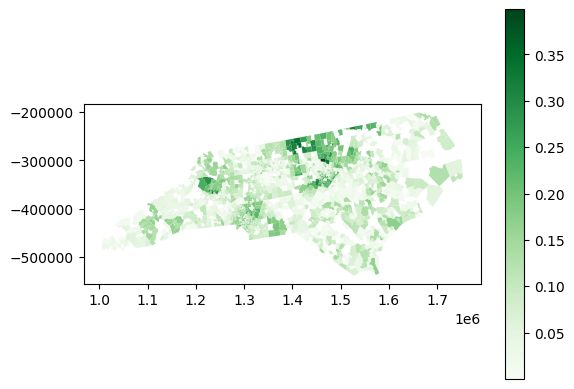

In [146]:
race_party_precincts.plot("abs_difference",legend=True,cmap="Greens")

In [24]:
dislocation_difference = dislocation_p["partisan_dislocation"] - dislocation_b["partisan_dislocation"]

In [25]:
dislocation_difference.head()

0   -0.131803
1   -0.158946
2   -0.131803
3   -0.153231
4   -0.134660
Name: partisan_dislocation, dtype: float64